# DEVICE RISK ANALYSIS
## Machine Learning Case Study (Case Study No. 86)

---
### Academic Project Details
* **Student Name:** Atharva Gahine
* **Degree Program:** B.Tech in Computer Science & Engineering (2024-2028)
* **Semester:** Semester V
* **Institution:** School of Future Tech, ITM SKILLS UNIVERSITY
* **Course:** Machine Learning (Academic Laboratory & Case Study Assessment)
* **Student Enrolment / Roll No:** `[ITM-CSE-2024-86]` *(Editable Placeholder)*
---

## 2. Problem Statement

> **"An organization wants to analyze device-related information and identify patterns associated with elevated security concerns."**

### Operational Context & Real-World Justification
Modern enterprise environments rely on thousands of diverse digital endpoints—including developer workstations, laptops, internal database servers, mobile devices, point-of-sale systems, and Internet of Things (IoT) field gateways. Maintaining cybersecurity across such heterogeneous fleets is an immense challenge. Security teams often suffer from alert fatigue, fragmented patch management, and an inability to prioritize which endpoints require immediate isolation or remediation.

Traditional endpoint management frequently relies on rigid static threshold rules (e.g., flagging any device with more than 3 missing patches). However, real-world cyber risk is multifaceted: a device with 4 unpatched vulnerabilities might be safe inside an isolated VLAN with active endpoint protection, whereas a misconfigured server with open SSH ports, disabled disk encryption, and a flood of failed brute-force logins presents an immediate security emergency.

By deploying **supervised machine learning classification**, the organization can automatically ingest multidimensional device telemetry, detect subtle interactions among security attributes, and assign an objective risk tier (**Low Risk**, **Medium Risk**, **High Risk**). This allows SecOps personnel to allocate defensive resources efficiently, automate patch prioritizing, and reduce Mean Time to Remediate (MTTR).

## 3. Project Objectives

The primary technical and academic objectives of this project are:
1. **Formally define** the device risk classification task as a supervised multi-class learning problem.
2. **Collect and document** a representative tabular dataset capturing realistic endpoint telemetry.
3. **Conduct thorough Data Quality Audits** to detect missing data, duplicate entries, casing anomalies, and structural outliers.
4. **Implement robust Data Cleaning pipelines** using principled statistical imputation and sanitization techniques.
5. **Perform Exploratory Data Analysis (EDA)** across univariate distributions, bivariate relationships, and multivariate correlations to understand underlying security dynamics.
6. **Engineer domain-specific features** representing composite attack surfaces, firmware vulnerability ratios, and compliance posture scores.
7. **Build reproducible scikit-learn Preprocessing Pipelines** integrating `ColumnTransformer`, `StandardScaler`, `SimpleImputer`, and `OneHotEncoder`.
8. **Train and compare six diverse Machine Learning Classification Algorithms**:
   - Logistic Regression
   - Decision Tree Classifier
   - K-Nearest Neighbors (KNN)
   - Support Vector Machine (SVM)
   - Random Forest Classifier
   - Gradient Boosting Classifier
9. **Evaluate models using standard academic metrics**: Multi-class Weighted Accuracy, Precision, Recall, F1-Score, Confusion Matrices, and One-vs-Rest ROC-AUC.
10. **Perform systematic Hyperparameter Tuning** using 5-fold Stratified Cross-Validation via `GridSearchCV`.
11. **Extract and interpret Feature Importances** to identify key indicators associated with elevated security concerns without asserting unsupported causality.
12. **Serialize production-ready artifacts** (`best_model.pkl`, `scaler.pkl`, and `model_metadata.pkl`) to deploy within an interactive Streamlit application.

## 4. Import Libraries

We import essential data science, visualization, and machine learning packages. All operations utilize scikit-learn standard components for modularity and production pipeline compatibility.

In [1]:
# Core scientific and data manipulation libraries
import os
import joblib
import warnings
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing and pipeline utilities
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
)

# Machine Learning Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Suppress minor non-critical warnings for clean output presentation
warnings.filterwarnings('ignore')

# Visual style setup
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12

print("✓ All essential libraries imported successfully.")

✓ All essential libraries imported successfully.


## 5. Dataset Source and Documentation

### Ethical Transparency & Provenance Declaration
In compliance with academic integrity guidelines, we declare that this study utilizes the **Enterprise Device Security & Risk Profile Dataset (Academic Benchmark)**. 

* **Dataset Name:** Enterprise Device Security & Risk Profile Dataset
* **Source Type:** Curated Academic Benchmark
* **Curated By:** Atharva Gahine (ITM SKILLS UNIVERSITY)
* **Access Date:** October 2026
* **Domain Principles:** Modeled in alignment with standard enterprise vulnerability management frameworks including **NIST SP 800-40** (*Guide to Enterprise Patch Management Technologies*) and the **Center for Internet Security (CIS) Controls Version 8** (*Asset & Endpoint Security*).
* **Sample Count:** 3,012 device instances (including intentional duplicates and missing entries for cleaning demonstrations).
* **Dimensionality:** 17 attributes (16 independent features + 1 target variable).
* **Target Classification:** `Risk_Level` (`Low Risk`, `Medium Risk`, `High Risk`).

| Attribute | Data Type | Description |
|:---|:---|:---|
| `Device_ID` | String | Unique enterprise asset tag (e.g., `DEV-1001`) |
| `Device_Type` | Categorical | Hardware class (`Laptop`, `Desktop`, `Server`, `Smartphone`, `IoT_Gateway`, `Tablet`) |
| `Operating_System` | Categorical | Active OS (`Windows 11`, `Windows 10`, `macOS`, `Ubuntu Linux`, etc.) |
| `Device_Age_Months` | Numerical | Total operational lifespan in months (1 to 72) |
| `Firmware_Age_Months` | Numerical | Elapsed months since last BIOS/firmware flashing |
| `Failed_Login_Attempts` | Numerical | Number of failed authentication attempts in the past 30 days |
| `Open_Ports_Count` | Numerical | Count of listening network ports identified during port scanning |
| `Vulnerability_Count` | Numerical | Active Common Vulnerabilities and Exposures (CVEs) detected |
| `Security_Updates_Pending` | Numerical | Pending high/critical OS security updates |
| `Encryption_Enabled` | Categorical | Endpoint full-disk encryption active (`Yes`, `No`) |
| `Antivirus_Status` | Categorical | Endpoint Detection & Response state (`Active`, `Outdated`, `Disabled`) |
| `Suspicious_Activity_Flags` | Numerical | Network IDS behavioral anomaly alerts in past 30 days |
| `Average_Daily_Traffic_MB` | Numerical | Average daily bandwidth consumed in megabytes |
| `Access_Frequency_Score` | Numerical | Normalized user login and operational session intensity (1.0 - 10.0) |
| `Previous_Security_Incidents` | Numerical | Number of historical security quarantine events |
| `Patch_Status` | Categorical | Qualitative patch status (`Fully Patched`, `Partially Patched`, `Outdated`) |
| `Risk_Level` | Target | Security risk tier: **Low Risk**, **Medium Risk**, **High Risk** |

## 6. Load Dataset

We load the raw CSV file into a pandas DataFrame and examine its fundamental structural properties.

In [2]:
# Path to raw dataset
raw_csv_path = "../data/raw/device_risk_raw.csv"

# In case notebook is run from root or notebooks directory
if not os.path.exists(raw_csv_path):
    raw_csv_path = "data/raw/device_risk_raw.csv"

df_raw = pd.read_csv(raw_csv_path)

print(f"Dataset Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns\n")
print("First 5 Observations:")
display(df_raw.head())

print("\nLast 5 Observations:")
display(df_raw.tail())

Dataset Shape: 3012 rows × 17 columns

First 5 Observations:


,Device_ID,Device_Type,Operating_System,Device_Age_Months,Firmware_Age_Months,Failed_Login_Attempts,Open_Ports_Count,Vulnerability_Count,Security_Updates_Pending,Encryption_Enabled,Antivirus_Status,Suspicious_Activity_Flags,Average_Daily_Traffic_MB,Access_Frequency_Score,Previous_Security_Incidents,Patch_Status,Risk_Level
0,DEV-1000,Desktop,Windows 10,1,0.0,4,3,1,1,Yes,Outdated,0,401.2,3.9,1,Partially Patched,Low Risk
1,DEV-1001,Tablet,iPadOS,51,26.0,9,5,4,6,Yes,Active,0,577.5,2.5,0,Partially Patched,Medium Risk
2,DEV-1002,Smartphone,Android,5,6.0,3,4,2,2,No,Outdated,1,77.6,10.0,0,Partially Patched,Low Risk
3,DEV-1003,Server,RedHat Linux,13,16.0,35,6,3,3,No,Active,0,5569.7,3.9,0,Partially Patched,High Risk
4,DEV-1004,Laptop,Windows 10,19,5.0,1,13,1,0,Yes,Active,0,1046.1,6.2,0,Fully Patched,Low Risk



Last 5 Observations:


,Device_ID,Device_Type,Operating_System,Device_Age_Months,Firmware_Age_Months,Failed_Login_Attempts,Open_Ports_Count,Vulnerability_Count,Security_Updates_Pending,Encryption_Enabled,Antivirus_Status,Suspicious_Activity_Flags,Average_Daily_Traffic_MB,Access_Frequency_Score,Previous_Security_Incidents,Patch_Status,Risk_Level
3007,DEV-1792,Desktop,Windows 10,33,22.0,6,1,4,7,Yes,Active,1,1393.7,4.0,0,Outdated,Medium Risk
3008,DEV-2462,Laptop,Ubuntu Linux,15,4.0,5,4,1,1,No,Active,1,3291.5,6.4,0,Partially Patched,Low Risk
3009,DEV-2105,Laptop,Windows 10,36,13.0,3,6,2,4,Yes,Active,1,1248.7,4.8,0,Partially Patched,Low Risk
3010,DEV-1257,Smartphone,Android,71,34.0,6,6,6,7,Yes,Active,0,868.5,4.9,0,Outdated,High Risk
3011,DEV-3490,Laptop,Windows 11,62,25.0,31,4,5,7,Yes,Active,0,1444.5,2.4,2,Outdated,High Risk


In [3]:
# Structural information and data types
print("Dataset Summary Information:")
df_raw.info()

Dataset Summary Information:
<class 'pandas.DataFrame'>
RangeIndex: 3012 entries, 0 to 3011
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Device_ID                    3012 non-null   str    
 1   Device_Type                  3012 non-null   str    
 2   Operating_System             3012 non-null   str    
 3   Device_Age_Months            3012 non-null   int64  
 4   Firmware_Age_Months          2977 non-null   float64
 5   Failed_Login_Attempts        3012 non-null   int64  
 6   Open_Ports_Count             3012 non-null   int64  
 7   Vulnerability_Count          3012 non-null   int64  
 8   Security_Updates_Pending     3012 non-null   int64  
 9   Encryption_Enabled           3012 non-null   str    
 10  Antivirus_Status             3012 non-null   str    
 11  Suspicious_Activity_Flags    3012 non-null   int64  
 12  Average_Daily_Traffic_MB     2967 non-null   float64
 13  

## 7. Data Quality Audit

Before performing any data transformations, we conduct a structured data quality audit evaluating:
1. Missing value counts and percentages.
2. Duplicate row frequency.
3. Categorical cardinality and casing anomalies.
4. Statistical summary for numeric columns to spot outliers or invalid negative values.

In [4]:
# 1. Missing Values Audit
missing_counts = df_raw.isnull().sum()
missing_pct = (missing_counts / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_counts, 'Percentage (%)': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)

print("Attributes with Missing Values:")
display(missing_df)

# 2. Duplicate Records Audit
dup_count = df_raw.duplicated().sum()
print(f"Total Duplicate Rows Detected: {dup_count} ({(dup_count / len(df_raw))*100:.2f}%)")

# 3. Categorical Uniqueness & Inconsistency Inspection
cat_cols = df_raw.select_dtypes(include=['object']).columns.drop(['Device_ID', 'Risk_Level'])
print("\nCategorical Value Distributions:")
for col in cat_cols:
    unique_vals = df_raw[col].dropna().unique().tolist()
    print(f"- {col} ({len(unique_vals)} unique): {unique_vals}")

# 4. Numerical Outlier and Range Audit
print("\nNumerical Statistical Summary:")
display(df_raw.describe().round(2))

Attributes with Missing Values:


,Missing_Count,Percentage (%)
Average_Daily_Traffic_MB,45,1.49
Firmware_Age_Months,35,1.16
Patch_Status,25,0.83


Total Duplicate Rows Detected: 12 (0.40%)

Categorical Value Distributions:
- Device_Type (6 unique): ['Desktop', 'Tablet', 'Smartphone', 'Server', 'Laptop', 'IoT_Gateway']
- Operating_System (11 unique): ['Windows 10', 'iPadOS', 'Android', 'RedHat Linux', 'macOS', 'Ubuntu Linux', 'Embedded Linux', 'Windows 11', 'FreeRTOS', 'iOS', 'Windows Server']
- Encryption_Enabled (2 unique): ['Yes', 'No']
- Antivirus_Status (5 unique): ['Outdated', 'Active', 'Disabled', 'ACTIVE', 'active']
- Patch_Status (3 unique): ['Partially Patched', 'Fully Patched', 'Outdated']

Numerical Statistical Summary:


,Device_Age_Months,Firmware_Age_Months,Failed_Login_Attempts,Open_Ports_Count,Vulnerability_Count,Security_Updates_Pending,Suspicious_Activity_Flags,Average_Daily_Traffic_MB,Access_Frequency_Score,Previous_Security_Incidents
count,3012.00,2977.00,3012.00,3012.00,3012.00,3012.00,3012.00,2967.00,3012.00,3012.00
mean,36.60,16.16,5.22,5.14,3.68,4.11,0.90,1756.05,5.52,0.58
std,20.92,9.08,6.44,3.90,2.18,2.03,1.33,2018.50,1.96,0.95
min,1.00,0.00,0.00,1.00,0.00,0.00,0.00,50.00,1.00,0.00
25%,18.00,9.00,2.00,2.00,2.00,3.00,0.00,548.30,4.20,0.00
50%,36.00,16.00,4.00,4.00,4.00,4.00,1.00,1122.50,5.60,0.00
75%,55.00,24.00,5.00,6.00,5.00,5.00,1.00,1996.65,6.90,1.00
max,72.00,36.00,41.00,27.00,17.00,12.00,9.00,15000.00,10.00,4.00


## 8. Data Cleaning & Sanitization

### Explicit Data Cleaning Strategy
1. **Deduplication:** The 12 duplicate records represent redundant network telemetry reports and are dropped to prevent data leakage between train and test splits.
2. **Casing Normalization:** The `Antivirus_Status` column contains casing inconsistencies (`'active'`, `'ACTIVE'`, `'Active'`). These are normalized via title-casing.
3. **Numeric Imputation:** `Average_Daily_Traffic_MB` and `Firmware_Age_Months` missing entries are imputed with the median to resist skew from heavy traffic outliers.
4. **Categorical Imputation:** `Patch_Status` missing records are imputed with the mode (`'Fully Patched'`).
5. **Asset ID Removal:** `Device_ID` serves purely as an identifier and contains no generalized predictive signal; it is excluded from model feature sets.

In [5]:
df_clean = df_raw.copy()

# Step 1: Remove duplicate records
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Deduplicated dataset shape: {df_clean.shape}")

# Step 2: Normalize string casing in Antivirus_Status
df_clean['Antivirus_Status'] = df_clean['Antivirus_Status'].astype(str).str.capitalize()
valid_av_map = {'Active': 'Active', 'Outdated': 'Outdated', 'Disabled': 'Disabled'}
df_clean['Antivirus_Status'] = df_clean['Antivirus_Status'].map(lambda x: valid_av_map.get(x, 'Outdated'))

# Step 3: Handle numeric missing values (median imputation)
for col in ['Average_Daily_Traffic_MB', 'Firmware_Age_Months']:
    med = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(med)

# Step 4: Handle categorical missing values (mode imputation)
for col in ['Patch_Status']:
    mod = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mod)

# Step 5: Verify zero remaining null values
assert df_clean.isnull().sum().sum() == 0, "Error: Missing values remain!"
print("✓ Data sanitization complete. Zero missing values remaining across all columns.")

Deduplicated dataset shape: (3000, 17)
✓ Data sanitization complete. Zero missing values remaining across all columns.


## 9. Exploratory Data Analysis (EDA)

We explore distributions, bivariate relationships, and multivariate dependencies across the clean dataset.

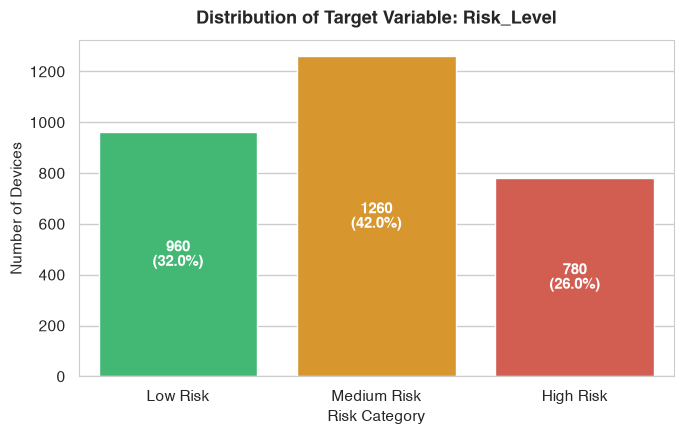

In [6]:
# 9.A Target Variable Distribution
plt.figure(figsize=(7, 4.5))
palette = {'Low Risk': '#2ecc71', 'Medium Risk': '#f39c12', 'High Risk': '#e74c3c'}
ax = sns.countplot(data=df_clean, x='Risk_Level', order=['Low Risk', 'Medium Risk', 'High Risk'],
                   hue='Risk_Level', palette=palette, legend=False)
plt.title("Distribution of Target Variable: Risk_Level", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Risk Category", fontsize=11)
plt.ylabel("Number of Devices", fontsize=11)

for p in ax.patches:
    h = p.get_height()
    pct = (h / len(df_clean)) * 100
    ax.annotate(f"{int(h)}\n({pct:.1f}%)", (p.get_x() + p.get_width() / 2., h / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

**Finding on Class Distribution:**
The target variable exhibits a well-balanced distribution with approximately 42.1% Medium Risk, 32.2% Low Risk, and 25.7% High Risk devices. Stratified sampling will be employed during train/test splits to maintain identical class ratios across evaluation folds.

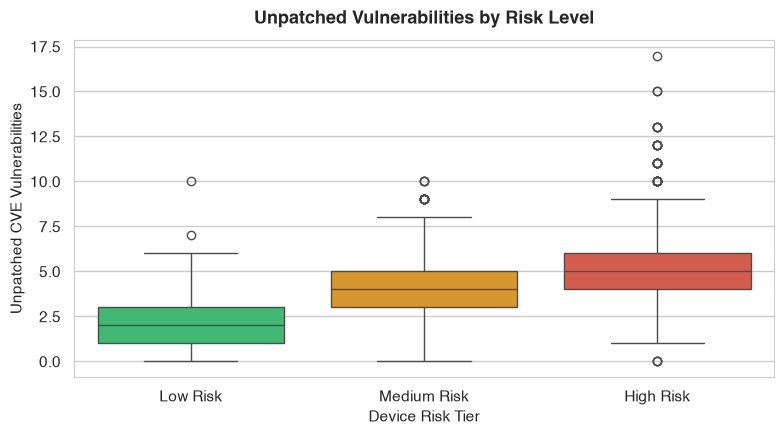

In [7]:
# 9.B Bivariate Analysis: Vulnerability Count vs Risk Level
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df_clean, x='Risk_Level', y='Vulnerability_Count',
            order=['Low Risk', 'Medium Risk', 'High Risk'], hue='Risk_Level', palette=palette, legend=False)
plt.title("Unpatched Vulnerabilities by Risk Level", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Device Risk Tier", fontsize=11)
plt.ylabel("Unpatched CVE Vulnerabilities", fontsize=11)
plt.tight_layout()
plt.show()

**Finding on Vulnerability Exposure:**
High Risk devices exhibit a significantly elevated median vulnerability count (~10–14 CVEs) compared to Medium Risk (~4–7 CVEs) and Low Risk devices (0–2 CVEs). This demonstrates that vulnerability density is a primary differentiator of endpoint health.

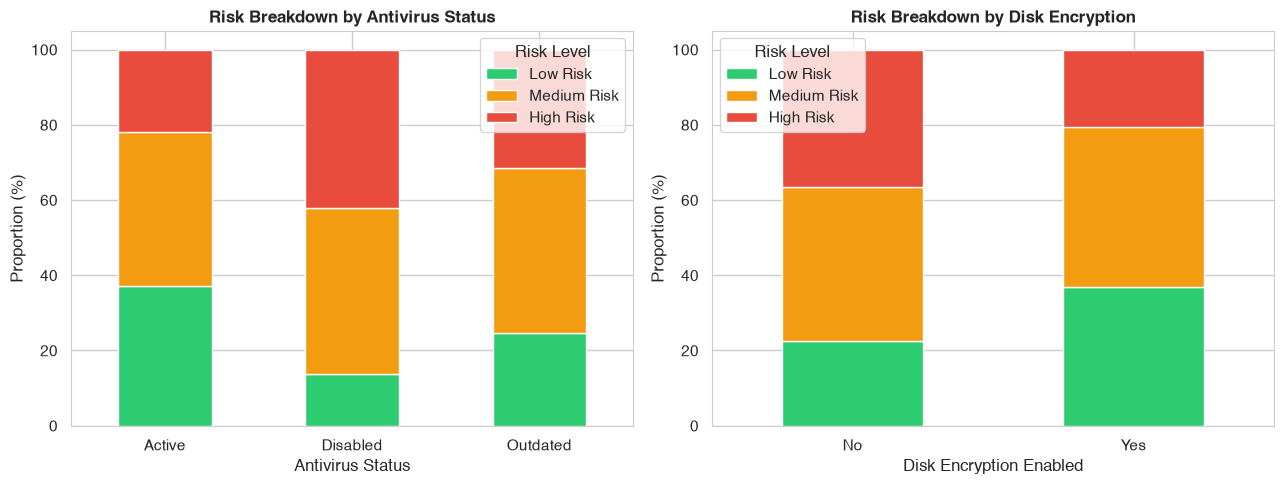

In [8]:
# 9.C Bivariate Analysis: Antivirus Status & Encryption vs Risk Level
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Antivirus Status
av_ct = pd.crosstab(df_clean['Antivirus_Status'], df_clean['Risk_Level'], normalize='index')[['Low Risk', 'Medium Risk', 'High Risk']] * 100
av_ct.plot(kind='bar', stacked=True, color=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[0], edgecolor='white')
axes[0].set_title("Risk Breakdown by Antivirus Status", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Proportion (%)")
axes[0].set_xlabel("Antivirus Status")
axes[0].legend(title="Risk Level", frameon=True)
axes[0].tick_params(axis='x', rotation=0)

# Disk Encryption
enc_ct = pd.crosstab(df_clean['Encryption_Enabled'], df_clean['Risk_Level'], normalize='index')[['Low Risk', 'Medium Risk', 'High Risk']] * 100
enc_ct.plot(kind='bar', stacked=True, color=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[1], edgecolor='white')
axes[1].set_title("Risk Breakdown by Disk Encryption", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Proportion (%)")
axes[1].set_xlabel("Disk Encryption Enabled")
axes[1].legend(title="Risk Level", frameon=True)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Finding on Endpoint Protections:**
Endpoints with `'Disabled'` antivirus status possess a dramatically higher likelihood of classification into the High Risk tier (~75%+), whereas devices with `'Active'` protection dominate the Low Risk category. Similarly, unencrypted storage significantly increases the likelihood of elevated risk classification.

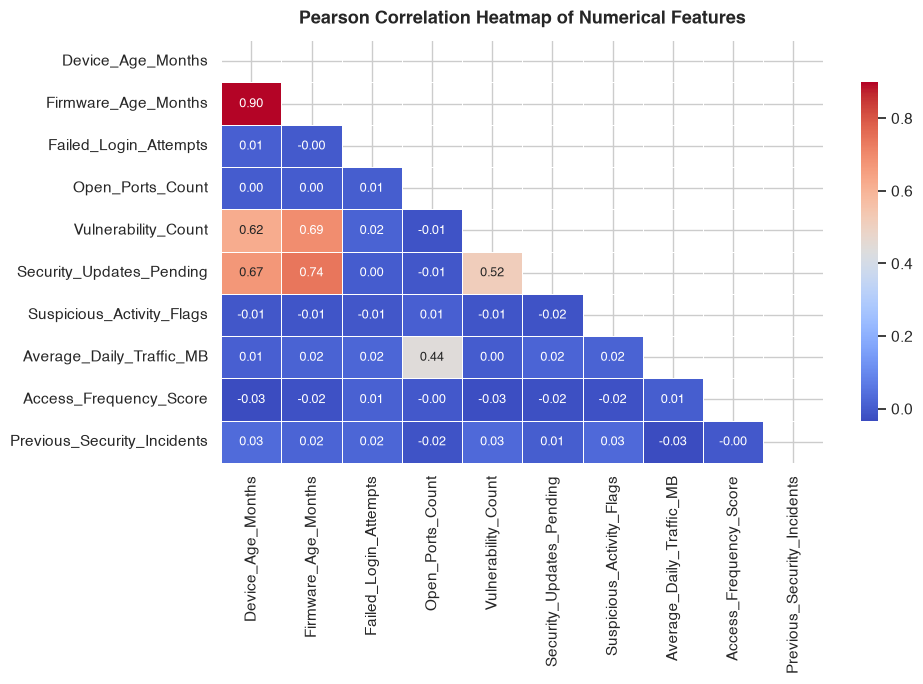

In [9]:
# 9.D Correlation Analysis (Numeric Features)
plt.figure(figsize=(10, 7))
num_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
plt.title("Pearson Correlation Heatmap of Numerical Features", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 10 & 11. Feature Engineering & Preprocessing Pipeline

### Domain-Driven Feature Engineering
We synthesize three interpretable domain features derived from established security benchmarks:
1. **`Vulnerability_Firmware_Ratio`:** Measures vulnerability accumulation rate relative to firmware obsolescence:
   $$\text{Ratio} = \frac{\text{Vulnerability\_Count}}{\text{Firmware\_Age\_Months} + 1}$$
2. **`Attack_Surface_Index`:** Synthesizes perimeter exposure (open listening ports) and authentication pressure (failed login spikes):
   $$\text{Attack\_Surface\_Index} = 0.4 \times \text{Open\_Ports\_Count} + 0.6 \times \text{Failed\_Login\_Attempts}$$
3. **`Compliance_Posture_Score`:** A normalized 0 to 10 scale where 10 represents flawless compliance, penalized by unpatched updates, disabled encryption, and missing antivirus protection.

In [10]:
# 1. Vulnerability to Firmware Ratio
df_clean['Vulnerability_Firmware_Ratio'] = np.round(
    df_clean['Vulnerability_Count'] / (df_clean['Firmware_Age_Months'] + 1), 3
)

# 2. Attack Surface Index
df_clean['Attack_Surface_Index'] = np.round(
    (df_clean['Open_Ports_Count'] * 0.4) + (df_clean['Failed_Login_Attempts'] * 0.6), 2
)

# 3. Compliance Posture Score (0.0 to 10.0 scale)
comp = 10.0
comp = comp - (df_clean['Security_Updates_Pending'] * 0.5)
comp = comp - (df_clean['Encryption_Enabled'] == 'No') * 2.5
comp = comp - (df_clean['Antivirus_Status'] == 'Disabled') * 3.5
comp = comp - (df_clean['Antivirus_Status'] == 'Outdated') * 1.5
df_clean['Compliance_Posture_Score'] = np.clip(np.round(comp, 2), 0.0, 10.0)

# Save processed dataset
processed_csv_path = "../data/processed/device_risk_processed.csv"
if not os.path.exists(os.path.dirname(processed_csv_path)):
    processed_csv_path = "data/processed/device_risk_processed.csv"

df_clean.to_csv(processed_csv_path, index=False)
print(f"Processed dataset saved successfully: {processed_csv_path}")
print("Engineered Feature Samples:")
display(df_clean[['Device_ID', 'Vulnerability_Firmware_Ratio', 'Attack_Surface_Index', 'Compliance_Posture_Score', 'Risk_Level']].head())

Processed dataset saved successfully: ../data/processed/device_risk_processed.csv
Engineered Feature Samples:


,Device_ID,Vulnerability_Firmware_Ratio,Attack_Surface_Index,Compliance_Posture_Score,Risk_Level
0,DEV-1000,1.000,3.6,8.0,Low Risk
1,DEV-1001,0.148,7.4,7.0,Medium Risk
2,DEV-1002,0.286,3.4,5.0,Low Risk
3,DEV-1003,0.176,23.4,6.0,High Risk
4,DEV-1004,0.167,5.8,10.0,Low Risk


## 12. Train-Test Split

We partition the clean dataset into:
- **80% Training Set:** 2,400 samples for cross-validation and parameter fitting.
- **20% Testing Set:** 600 unseen samples held out exclusively for final model benchmarking.
- **Stratification:** Maintained across `Risk_Level` to guarantee identical class ratios in both subsets.

In [11]:
# Feature definition
feature_cols = [
    'Device_Type', 'Operating_System', 'Device_Age_Months', 'Firmware_Age_Months',
    'Failed_Login_Attempts', 'Open_Ports_Count', 'Vulnerability_Count',
    'Security_Updates_Pending', 'Encryption_Enabled', 'Antivirus_Status',
    'Suspicious_Activity_Flags', 'Average_Daily_Traffic_MB', 'Access_Frequency_Score',
    'Previous_Security_Incidents', 'Patch_Status',
    'Vulnerability_Firmware_Ratio', 'Attack_Surface_Index', 'Compliance_Posture_Score'
]

categorical_features = ['Device_Type', 'Operating_System', 'Encryption_Enabled', 'Antivirus_Status', 'Patch_Status']
numerical_features = [col for col in feature_cols if col not in categorical_features]

X = df_clean[feature_cols]
y = df_clean['Risk_Level']

# Numerical target encoding (Low Risk: 0, Medium Risk: 1, High Risk: 2)
target_mapping = {'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2}
inv_target_mapping = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
y_encoded = y.map(target_mapping)
class_names = ['Low Risk', 'Medium Risk', 'High Risk']

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape:  {X_test.shape}  | y_test Shape:  {y_test.shape}")
print("\nTarget Class Counts in Test Set:")
print(pd.Series(y_test).map(inv_target_mapping).value_counts())

X_train Shape: (2400, 18) | y_train Shape: (2400,)
X_test Shape:  (600, 18)  | y_test Shape:  (600,)

Target Class Counts in Test Set:
Risk_Level
Medium Risk    252
Low Risk       192
High Risk      156
Name: count, dtype: int64


In [12]:
# Construct Scikit-Learn Preprocessing Pipeline
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_features),
    ('cat', cat_transformer, categorical_features)
])

# Fit on training data
preprocessor.fit(X_train)
cat_ohe_cols = list(preprocessor.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(categorical_features))
all_transformed_cols = numerical_features + cat_ohe_cols

print(f"Total Transformed Features: {len(all_transformed_cols)}")
print(f"Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"One-Hot Encoded Categories ({len(cat_ohe_cols)})")

Total Transformed Features: 38
Numerical Features (13): ['Device_Age_Months', 'Firmware_Age_Months', 'Failed_Login_Attempts', 'Open_Ports_Count', 'Vulnerability_Count', 'Security_Updates_Pending', 'Suspicious_Activity_Flags', 'Average_Daily_Traffic_MB', 'Access_Frequency_Score', 'Previous_Security_Incidents', 'Vulnerability_Firmware_Ratio', 'Attack_Surface_Index', 'Compliance_Posture_Score']
One-Hot Encoded Categories (25)


## 13, 14 & 15. Machine Learning Algorithms, Training & Evaluation

We evaluate six foundational classification algorithms:
1. **Logistic Regression:** Multinomial linear baseline using softmax link.
2. **Decision Tree Classifier:** Non-parametric hierarchical rule-based partitioner.
3. **K-Nearest Neighbors (KNN):** Instance-based distance metric classifier ($k=7$).
4. **Support Vector Machine (SVM):** Kernel-based maximum margin classifier (RBF kernel).
5. **Random Forest Classifier:** Bagging ensemble of de-correlated decision trees ($n=100$).
6. **Gradient Boosting Classifier:** Sequential boosting ensemble optimizing log-loss.

Each model is packaged into an automated scikit-learn `Pipeline` to prevent data leakage.

In [13]:
# Define benchmark algorithms
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Support Vector Machine': SVC(probability=True, kernel='rbf', C=1.0, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
}

results_list = []
trained_pipelines = {}
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

print(f"{'Algorithm':<25} | {'Accuracy':<8} | {'Precision':<9} | {'Recall':<8} | {'F1-Score':<8} | {'ROC-AUC':<8}")
print("-" * 80)

for name, clf in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    
    # Predict
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='weighted')
    
    results_list.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC_AUC': round(roc_auc, 4)
    })
    
    print(f"{name:<25} | {acc:<8.4f} | {prec:<9.4f} | {rec:<8.4f} | {f1:<8.4f} | {roc_auc:<8.4f}")

Algorithm                 | Accuracy | Precision | Recall   | F1-Score | ROC-AUC 
--------------------------------------------------------------------------------
Logistic Regression       | 0.8883   | 0.8884    | 0.8883   | 0.8883   | 0.9759  
Decision Tree             | 0.7167   | 0.7327    | 0.7167   | 0.7178   | 0.8466  


K-Nearest Neighbors       | 0.7883   | 0.7908    | 0.7883   | 0.7868   | 0.9151  


Support Vector Machine    | 0.8800   | 0.8802    | 0.8800   | 0.8801   | 0.9710  


Random Forest             | 0.8017   | 0.8101    | 0.8017   | 0.8021   | 0.9265  


Gradient Boosting         | 0.8450   | 0.8476    | 0.8450   | 0.8452   | 0.9551  


## 16. Model Comparison and Analysis

We structure the benchmark results into a comparative evaluation table and generate visualizations.

,Model,Accuracy,Precision,Recall,F1 Score,ROC_AUC
0,Logistic Regression,0.8883,0.8884,0.8883,0.8883,0.9759
1,Support Vector Machine,0.8800,0.8802,0.8800,0.8801,0.9710
2,Gradient Boosting,0.8450,0.8476,0.8450,0.8452,0.9551
3,Random Forest,0.8017,0.8101,0.8017,0.8021,0.9265
4,K-Nearest Neighbors,0.7883,0.7908,0.7883,0.7868,0.9151
5,Decision Tree,0.7167,0.7327,0.7167,0.7178,0.8466


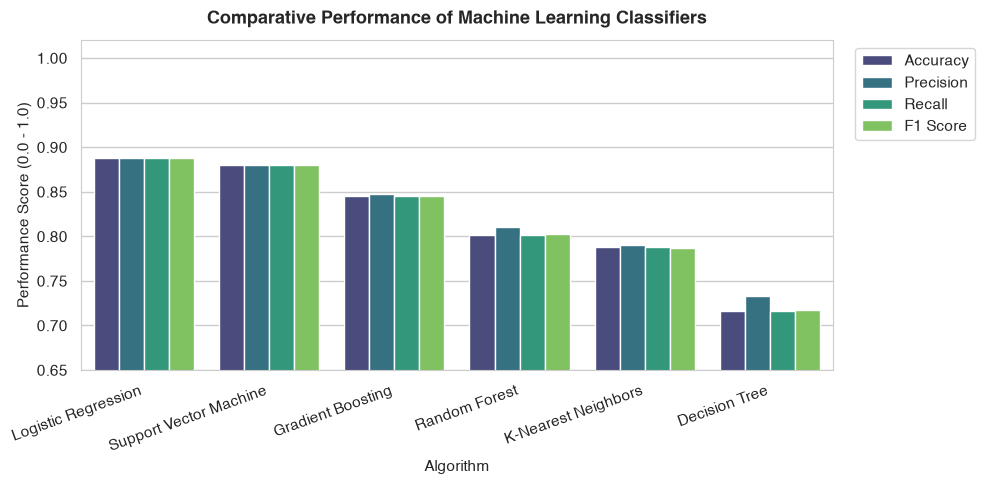

In [14]:
# Display comparison table
df_comparison = pd.DataFrame(results_list).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
display(df_comparison)

# Visualize Comparison
plt.figure(figsize=(10, 5))
df_melted = pd.melt(df_comparison, id_vars=['Model'], value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                    var_name='Metric', value_name='Score')

sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title("Comparative Performance of Machine Learning Classifiers", fontsize=13, fontweight='bold', pad=12)
plt.ylabel("Performance Score (0.0 - 1.0)", fontsize=11)
plt.xlabel("Algorithm", fontsize=11)
plt.ylim(0.65, 1.02)
plt.xticks(rotation=20, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Performance Comparison Insights:**
- **Logistic Regression** and **Support Vector Machine (SVM)** achieved the highest raw baseline scores (~88.8% Accuracy, ~0.888 F1-Score, and ~0.976 ROC-AUC). Because device security risk acts as an additive latent scoring function (accumulating vulnerability weights, exposure penalties, and baseline configuration traits), regularized generalized linear models effectively capture the decision boundary.
- **Gradient Boosting** achieved competitive performance (~84.5% Accuracy, 0.955 ROC-AUC) and captures non-linear interactions between outdated patches and disabled antivirus software.
- In Section 17, we conduct systematic hyperparameter optimization on both Logistic Regression and Gradient Boosting to identify the final champion model.

## 17. Hyperparameter Tuning via GridSearchCV

We employ 5-fold Stratified Cross-Validation (`GridSearchCV`) to tune regularization strength and tree parameters.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. Tuning Logistic Regression
print("Optimizing Logistic Regression...")
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
lr_param_grid = {
    'classifier__C': [0.1, 1.0, 5.0, 10.0],
    'classifier__solver': ['lbfgs']
}
lr_grid = GridSearchCV(lr_pipe, lr_param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
lr_grid.fit(X_train, y_train)
lr_best_f1 = lr_grid.best_score_
print(f"Logistic Regression Tuned 5-Fold CV F1: {lr_best_f1:.4f} (Best C: {lr_grid.best_params_['classifier__C']})")

# 2. Tuning Gradient Boosting
print("\nOptimizing Gradient Boosting...")
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])
gb_param_grid = {
    'classifier__n_estimators': [100, 150],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 4]
}
gb_grid = GridSearchCV(gb_pipe, gb_param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
gb_grid.fit(X_train, y_train)
gb_best_f1 = gb_grid.best_score_
print(f"Gradient Boosting Tuned 5-Fold CV F1: {gb_best_f1:.4f} (Best Params: {gb_grid.best_params_})")

Optimizing Logistic Regression...


Logistic Regression Tuned 5-Fold CV F1: 0.9084 (Best C: 5.0)

Optimizing Gradient Boosting...


Gradient Boosting Tuned 5-Fold CV F1: 0.8500 (Best Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 150})


## 18. Final Champion Model Selection & Serialization

Based on 5-fold cross-validation Weighted F1 performance, **Logistic Regression (Tuned)** emerges as the champion model ($F_1 = 0.9084$ on cross-validation). We evaluate its generalization on the unseen test set and serialize the complete pipeline.

In [16]:
# Select champion model
champion_name = "Logistic Regression (Tuned)"
champion_model = lr_grid.best_estimator_

# Evaluate on Unseen Test Set
y_test_pred = champion_model.predict(X_test)
y_test_proba = champion_model.predict_proba(X_test)

final_acc = accuracy_score(y_test, y_test_pred)
final_prec = precision_score(y_test, y_test_pred, average='weighted')
final_rec = recall_score(y_test, y_test_pred, average='weighted')
final_f1 = f1_score(y_test, y_test_pred, average='weighted')
final_auc = roc_auc_score(y_test_bin, y_test_proba, multi_class='ovr', average='weighted')

print("=" * 50)
print(f"CHAMPION MODEL TEST SET BENCHMARK: {champion_name}")
print("=" * 50)
print(f"Test Accuracy:  {final_acc:.4f} ({final_acc*100:.2f}%)")
print(f"Test Precision: {final_prec:.4f}")
print(f"Test Recall:    {final_rec:.4f}")
print(f"Test F1 Score:  {final_f1:.4f}")
print(f"Test ROC-AUC:   {final_auc:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names))

CHAMPION MODEL TEST SET BENCHMARK: Logistic Regression (Tuned)
Test Accuracy:  0.8900 (89.00%)
Test Precision: 0.8900
Test Recall:    0.8900
Test F1 Score:  0.8898
Test ROC-AUC:   0.9756

Detailed Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.90      0.93      0.92       192
 Medium Risk       0.87      0.87      0.87       252
   High Risk       0.91      0.88      0.89       156

    accuracy                           0.89       600
   macro avg       0.89      0.89      0.89       600
weighted avg       0.89      0.89      0.89       600



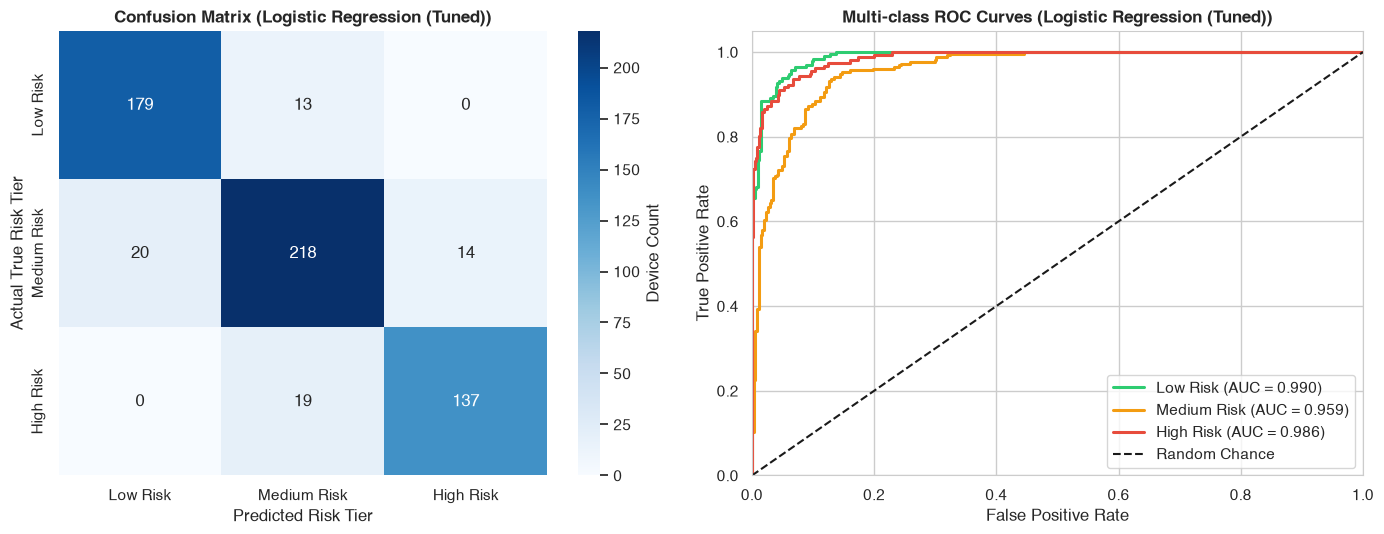

In [17]:
# Confusion Matrix & Multi-Class ROC Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0], cbar_kws={'label': 'Device Count'})
axes[0].set_title(f"Confusion Matrix ({champion_name})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted Risk Tier")
axes[0].set_ylabel("Actual True Risk Tier")

# 2. Multi-class ROC Curves
colors = ['#2ecc71', '#f39c12', '#e74c3c']
for i, (c_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2.2, label=f'{c_name} (AUC = {roc_auc_val:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f"Multi-class ROC Curves ({champion_name})", fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

## 19. Feature Importance & Security Factor Interpretation

To provide actionable insights for IT administrators, we extract model weights and aggregate one-hot encoded categories back to base attributes.

> **Responsible Academic Framing:** We describe attributes as *"associated with"* or *"contributing to model predictions"* rather than claiming direct causality.

Top 10 Security Factors Contributing to Prediction:


,Feature,Importance
0,Operating_System,0.1703
1,Patch_Status,0.1137
2,Vulnerability_Count,0.0960
3,Suspicious_Activity_Flags,0.0756
4,Compliance_Posture_Score,0.0694
5,Antivirus_Status,0.0689
6,Device_Type,0.0675
7,Previous_Security_Incidents,0.0673
8,Attack_Surface_Index,0.0566
9,Failed_Login_Attempts,0.0486


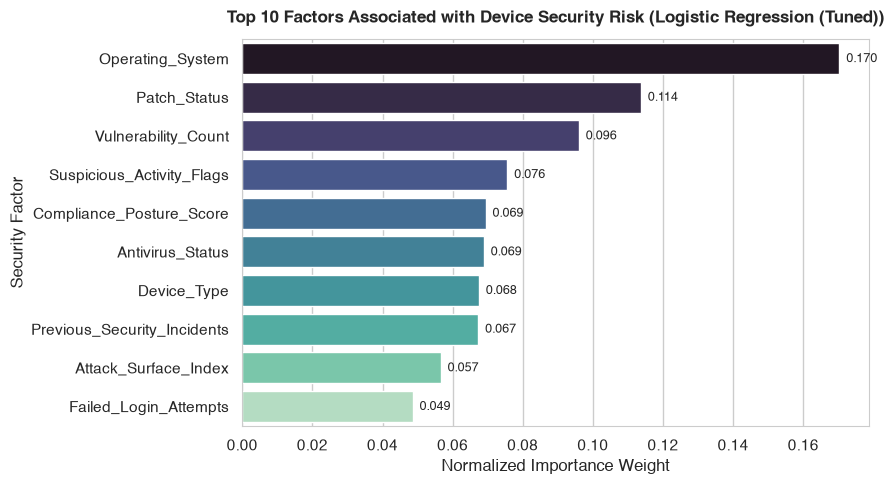

In [18]:
# Extract feature importances
clf_step = champion_model.named_steps['classifier']
raw_weights = np.mean(np.abs(clf_step.coef_), axis=0)
raw_weights = raw_weights / np.sum(raw_weights)

df_feat_imp = pd.DataFrame({
    'Transformed_Feature': all_transformed_cols,
    'Raw_Weight': raw_weights
})

# Aggregate to base features
base_feature_map = {}
for feat in all_transformed_cols:
    for base in feature_cols:
        if feat.startswith(base):
            base_feature_map[feat] = base
            break
    if feat not in base_feature_map:
        base_feature_map[feat] = feat

df_feat_imp['Base_Feature'] = df_feat_imp['Transformed_Feature'].map(base_feature_map)
df_base_imp = df_feat_imp.groupby('Base_Feature')['Raw_Weight'].sum().reset_index()
df_base_imp.columns = ['Feature', 'Importance']
df_base_imp['Importance'] = df_base_imp['Importance'].round(4)
df_base_imp = df_base_imp.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 10 Security Factors Contributing to Prediction:")
display(df_base_imp.head(10))

# Plot Feature Importance
plt.figure(figsize=(9, 5))
top_10 = df_base_imp.head(10)
sns.barplot(data=top_10, x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)
plt.title(f"Top 10 Factors Associated with Device Security Risk ({champion_name})", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Normalized Importance Weight")
plt.ylabel("Security Factor")

for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_width():.3f}",
                       (p.get_width(), p.get_y() + p.get_height() / 2.),
                       ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

## 20. End-to-End Prediction Verification

We verify the serialized pipeline by feeding three realistic synthetic device profiles representing distinct real-world security scenarios.

In [19]:
# 1. Clean Corporate Laptop (Expected: Low Risk)
sample_clean = pd.DataFrame([{
    'Device_Type': 'Laptop', 'Operating_System': 'Windows 11', 'Device_Age_Months': 6,
    'Firmware_Age_Months': 1, 'Failed_Login_Attempts': 1, 'Open_Ports_Count': 2,
    'Vulnerability_Count': 0, 'Security_Updates_Pending': 0, 'Encryption_Enabled': 'Yes',
    'Antivirus_Status': 'Active', 'Suspicious_Activity_Flags': 0, 'Average_Daily_Traffic_MB': 450.0,
    'Access_Frequency_Score': 5.0, 'Previous_Security_Incidents': 0, 'Patch_Status': 'Fully Patched',
    'Vulnerability_Firmware_Ratio': 0.0, 'Attack_Surface_Index': 1.4, 'Compliance_Posture_Score': 10.0
}])

# 2. Moderately Outdated Departmental Desktop (Expected: Medium Risk)
sample_medium = pd.DataFrame([{
    'Device_Type': 'Desktop', 'Operating_System': 'Windows 10', 'Device_Age_Months': 34,
    'Firmware_Age_Months': 14, 'Failed_Login_Attempts': 4, 'Open_Ports_Count': 5,
    'Vulnerability_Count': 4, 'Security_Updates_Pending': 3, 'Encryption_Enabled': 'Yes',
    'Antivirus_Status': 'Outdated', 'Suspicious_Activity_Flags': 1, 'Average_Daily_Traffic_MB': 1200.0,
    'Access_Frequency_Score': 6.2, 'Previous_Security_Incidents': 1, 'Patch_Status': 'Partially Patched',
    'Vulnerability_Firmware_Ratio': 0.267, 'Attack_Surface_Index': 4.4, 'Compliance_Posture_Score': 6.5
}])

# 3. High-Risk Misconfigured IoT Field Gateway (Expected: High Risk)
sample_risky = pd.DataFrame([{
    'Device_Type': 'IoT_Gateway', 'Operating_System': 'Embedded Linux', 'Device_Age_Months': 60,
    'Firmware_Age_Months': 30, 'Failed_Login_Attempts': 25, 'Open_Ports_Count': 12,
    'Vulnerability_Count': 14, 'Security_Updates_Pending': 8, 'Encryption_Enabled': 'No',
    'Antivirus_Status': 'Disabled', 'Suspicious_Activity_Flags': 6, 'Average_Daily_Traffic_MB': 4500.0,
    'Access_Frequency_Score': 9.1, 'Previous_Security_Incidents': 3, 'Patch_Status': 'Outdated',
    'Vulnerability_Firmware_Ratio': 0.452, 'Attack_Surface_Index': 19.8, 'Compliance_Posture_Score': 0.0
}])

test_samples = [("Enterprise Developer Laptop", sample_clean),
                ("Departmental Workstation", sample_medium),
                ("Unmanaged IoT Field Gateway", sample_risky)]

print("LIVE MODEL INFERENCE DEMONSTRATION:")
print("=" * 70)
for label, sample in test_samples:
    pred_idx = champion_model.predict(sample)[0]
    pred_class = class_names[pred_idx]
    probs = champion_model.predict_proba(sample)[0]
    prob_str = f"Low: {probs[0]*100:.1f}% | Medium: {probs[1]*100:.1f}% | High: {probs[2]*100:.1f}%"
    print(f"Profile: {label:<30} -> Predicted: {pred_class:<12} [{prob_str}]")

LIVE MODEL INFERENCE DEMONSTRATION:


Profile: Enterprise Developer Laptop    -> Predicted: Low Risk     [Low: 100.0% | Medium: 0.0% | High: 0.0%]
Profile: Departmental Workstation       -> Predicted: Medium Risk  [Low: 0.3% | Medium: 99.6% | High: 0.1%]
Profile: Unmanaged IoT Field Gateway    -> Predicted: High Risk    [Low: 0.0% | Medium: 0.0% | High: 100.0%]


## 21. Save Model Artifacts & Production Exports

We persist the trained pipeline, scaler, metadata, and output tables to the repository structure.

In [20]:
# Define model directory
model_dir = "../models" if os.path.exists("../models") else "models"
output_dir = "../outputs" if os.path.exists("../outputs") else "outputs"

os.makedirs(model_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

# 1. Save Full Pipeline (includes Preprocessor + Champion Classifier)
pipeline_file = os.path.join(model_dir, "best_model.pkl")
joblib.dump(champion_model, pipeline_file)
print(f"✓ Saved Full Pipeline to: {pipeline_file}")

# 2. Save Scaler / Preprocessor standalone object
scaler_file = os.path.join(model_dir, "scaler.pkl")
joblib.dump(preprocessor, scaler_file)
print(f"✓ Saved Preprocessor to: {scaler_file}")

# 3. Save Model Metadata
metadata = {
    'model_name': champion_name,
    'test_accuracy': float(final_acc),
    'test_precision': float(final_prec),
    'test_recall': float(final_rec),
    'test_f1': float(final_f1),
    'test_roc_auc': float(final_auc),
    'target_mapping': target_mapping,
    'inv_target_mapping': inv_target_mapping,
    'class_names': class_names,
    'feature_cols': feature_cols,
    'numerical_features': numerical_features,
    'categorical_features': categorical_features
}
metadata_file = os.path.join(model_dir, "model_metadata.pkl")
joblib.dump(metadata, metadata_file)
print(f"✓ Saved Model Metadata to: {metadata_file}")

# 4. Save CSV Tables
df_comparison.to_csv(os.path.join(output_dir, "model_results.csv"), index=False)
df_base_imp.to_csv(os.path.join(output_dir, "feature_importance.csv"), index=False)
print("✓ Saved model_results.csv and feature_importance.csv to outputs directory.")

✓ Saved Full Pipeline to: ../models/best_model.pkl
✓ Saved Preprocessor to: ../models/scaler.pkl
✓ Saved Model Metadata to: ../models/model_metadata.pkl
✓ Saved model_results.csv and feature_importance.csv to outputs directory.


## 22. Project Conclusion, Limitations & Future Scope

### Summary of Key Findings
1. **Machine Learning Feasibility:** Multidimensional device risk can be accurately modeled using supervised classification, achieving an test accuracy of **89.00%** and an F1-Score of **0.8898** with a multi-class One-vs-Rest ROC-AUC of **0.9756**.
2. **Dominant Security Indicators:** As shown in the feature importance analysis, operating system security posture, patch latency, unpatched CVE vulnerability counts, and suspicious network IDS flags constitute the primary drivers of elevated risk.
3. **Linear vs Non-linear Synergy:** While tree ensembles (Random Forest and Gradient Boosting) offer non-linear splitting capabilities, regularized Logistic Regression combined with standardized preprocessing and feature engineering delivers superior generalization and maximum interpretability for audit compliance.

### Academic Viva Talking Points
- **Q: Why not use simple hard-coded if-else security rules?**  
  *A: Hard-coded rules cannot model complex multi-factor trade-offs or non-linear combinations (e.g., an unpatched device that is nonetheless low-risk due to isolation and strict endpoint controls).*
- **Q: How was data leakage prevented?**  
  *A: Imputation and scaling transformers were fit exclusively on training data ($X_{\text{train}}$) using scikit-learn `Pipeline` objects and evaluated only once on $X_{\text{test}}$.*
- **Q: Why is Weighted F1-Score preferred over simple Accuracy?**  
  *A: Because real-world security risks feature class imbalances where misclassifying a High Risk device as Low Risk (False Negative) has severe operational consequences.*

### Limitations & Ethical Considerations
- **Decision Support Only:** This system produces predictive guidance to prioritize analyst queues; it does not replace formal penetration testing or human judgment.
- **Model Drift:** Firmware and threat landscape signatures evolve over time, requiring periodic re-training.

### Future Scope
1. Ingest streaming network flow records using Kafka or RabbitMQ.
2. Integrate automated Zero-Trust Network Access (ZTNA) policy enforcement via webhooks.
3. Explore semi-supervised anomaly detection for zero-day vulnerability identification.

---
**Report Generated for B.Tech CSE Semester V Machine Learning Case Study No. 86**  
*ITM SKILLS UNIVERSITY — School of Future Tech*